# Anwendungen der Integration

## Vertiefung

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid

Matplotlib is building the font cache; this may take a moment.


### Übersicht

1. Mittelwert einer Funktion
2. Gewichteter Mittelwert und Skalarprodukt
3. Gleitender Mittelwert und Faltung von Daten
4. Faltung von Funktionen

### 1. Mittelwert einer Funktion

#### Jogging: Mittlere Geschwindigkeit

Wir benutzen nochmals die Jogging-Daten. Wie im Übungsblatt zur Integration laden wir die Daten und rechnen die Pace in die Geschwindigkeit in m/s um.

In [2]:
jogging = np.loadtxt("jogging.csv", delimiter=";", skiprows=1, usecols=(0, 1, 2))
time, distance, pace = jogging.T

t_max = 120
my_filter = (pace > 0) & (time <= t_max)

t_data = time[my_filter]
v_data = (1609.344 / 60) / pace[my_filter]

Nun ist die mittlere Geschwindigkeit gleich der zurückgelegten Strecke geteilt durch die Zeit:

$$ \overline{v} = \frac{s(t_{end}) - s(t_{start})}{t_{end} - t_{start}} $$

Weil die zurückgelegte Strecke $s(t)$ eine Stammfunktion der Geschwindigkeit $v(t)$ ist, können wir die mittlere Geschwindigkeit auch als Integral berechnen:

$$ s(t) = \int v(t) \,dt \qquad \Rightarrow \qquad \overline{v} = \frac{1}{t_{end} - t_{start}} \int_{t_{start}}^{t_{end}} v(t) \,dt $$

In [3]:
total_distance = trapezoid(v_data, t_data)
v_mean = total_distance / (t_data.max() - t_data.min())
v_mean

np.float64(3.495530561927936)

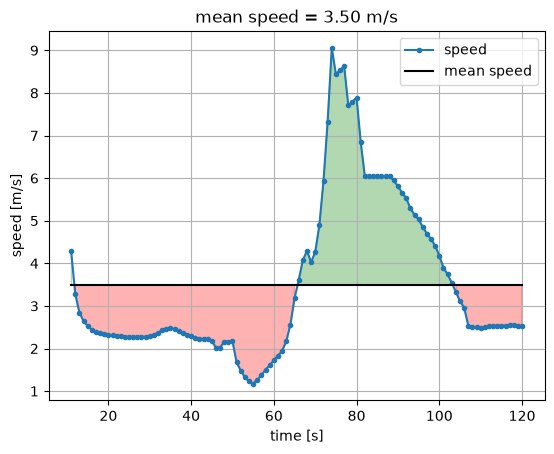

In [4]:
plt.plot(t_data, v_data, ".-", label="speed")
plt.plot(t_data, np.full_like(t_data, v_mean), "k", label="mean speed")
plt.fill_between(
    t_data,
    v_data,
    v_mean,
    where=v_data > v_mean,
    alpha=0.3,
    color="g",
)
plt.fill_between(
    t_data,
    v_data,
    v_mean,
    where=v_data < v_mean,
    alpha=0.3,
    color="r",
)
plt.xlabel("time [s]")
plt.ylabel("speed [m/s]")
plt.title(f"mean speed = {v_mean:.2f} m/s")
plt.legend()
plt.grid()
plt.show()

#### Unregelmäßige Daten

Mittelwert via Integration der Daten

In [5]:
v_mean

np.float64(3.495530561927936)

Mittelwert der Daten direkt stimmt praktisch überein, weil die Daten gleichmässig verteilt sind.

In [6]:
v_data.mean()

np.float64(3.4946686541818943)

Mittelwert über einen Teil der Daten stimmt nicht überein

In [7]:
rng = np.random.default_rng(42234098234)
sample_index = rng.choice([True, False], size=len(t_data))

v_data[sample_index].mean()

np.float64(3.8372847546527575)

Aber die Berechnung mithilfe des Integrals ist stabiler gegenüber ungleichmässiger Daten.

In [8]:
dist = trapezoid(v_data[sample_index], t_data[sample_index])
dist / (t_data[sample_index].max() - t_data[sample_index].min())

np.float64(3.5071185803425253)

### 2. Gewichteter Mittelwert und Skalarprodukt

#### Allgemein

Das gewichtete Mittel von Daten $\vec y \in \mathbb{R}^n$ mit normierten Gewichten $\vec w \in \mathbb{R}^n$ kann als Skalarprodukt geschrieben werden:

$$
    \overline{y} = \sum_{i=0}^{n-1} w_i y_i = \vec w \cdot \vec y
$$

Man erinnere sich an die Definition des Skalarprodukts in der Linearen Algebra. Dort zeigt man, dass es einen Zusammenhang zur Norm (Länge) der beiden Vektoren und zum Zwischenwinkel $\alpha$ gibt:

$$
    \vec w \cdot \vec y = \left| \vec w \right| \left| \vec y \right| \cos(\alpha)
$$

Die Norm selbst kann man auch verstehen als das Skalarprodukt eines Vektors mit sich selbst: $|\vec a| = \sqrt{\vec a \cdot \vec a}$.


![Zusammenhang zwischen Winkel und Skalarprodukt](skalarprodukt.png)


Das Skalarprodukt ist also die Projektion des einen Vektors auf den anderen multipliziert mit der Länge des anderen Vektors. Diese Projektion ist

- maximal, wenn die beiden Vektoren in die gleiche Richtung zeigen ($\alpha = 0$),
- minimal, wenn sie in entgegengesetzte Richtung zeigen ($\alpha = \pi = 180^\circ$) und
- null, wenn sie orthogonal sind ($\alpha = \frac{\pi}{2} = 90^\circ$).

Man kann also auch sagen, dass das Skalarprodukt **die Ähnlichkeit der beiden Vektoren** misst. 

Analog kann das Integral über ein Produkt zweier Funktionen als Skalarprodukt (auch inneres Produkt) interpretiert werden:

$$ \langle f, g \rangle = \int_a^b f(t) g(t) \,\mathrm{d}t $$

Bei Funktionen benutzt man die Schreibweise mit den Klammern $\langle\cdot,\cdot\rangle$ statt einem Punkt. Dies ist eine Verallgemeinerung des Skalarprodukts aus der linearen Algebra.

In diesem Sinn ist das Skalarprodukt zweier Funktionen ein **Mass für die Ähnlichkeit** der beiden Funktionen und kann als Projektion der einen Funktion auf die andere verstanden werden. Wenn es 0 ist, sind die Funktionen orthogonal, d.h. sie sind in einem gewissen Sinn unabhängig voneinander.

Bemerkung: Entsprechend kann man eine Norm (Länge), die $L^2$-Norm, einer Funktion definieren:

$$ \| f \|_2 = \sqrt{\langle f, f \rangle} = \sqrt{\int_a^b f(t)^2 \,\mathrm{d}t} $$

#### Beispiel 1

Das Skalarprodukt von $f(x)=x^2$ und $g(x)=x^3$ im Bereich $[-a,a]$ ist:

\begin{align*}
    \langle f, g \rangle
    &= \int_{-a}^a x^2 x^3 \,\mathrm{d}x \\
    &= \int_{-a}^a x^5 \,\mathrm{d}x \\
    &= \bigg[ \frac{1}{6}x^6 \bigg]_{-a}^a \\
    &= \frac{1}{6}\left(a^6 - (-a)^6\right) \\
    &= 0
\end{align*}

$f(x)=x^2$ und $g(x)=x^3$ sind also orthogonal. Allgemein sind gerade und ungerade Funktionen orthogonal, solange das Skalarprodukt auf einem symmetrischen Intervall $[-a,a]$ betrachtet wird.

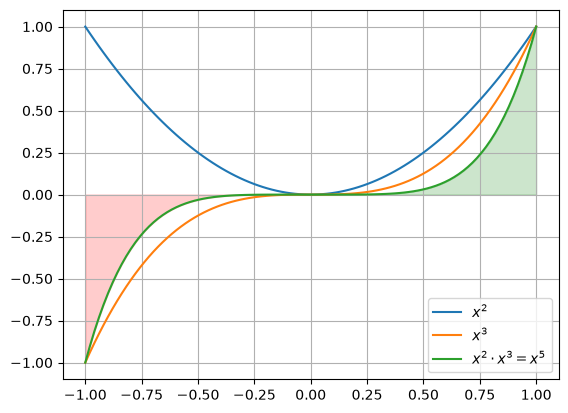

In [9]:
x = np.linspace(-1, 1, 100)
f = x**2
g = x**3
fg = f * g
plt.plot(x, f, label=r"$x^2$")
plt.plot(x, g, label=r"$x^3$")
plt.plot(x, fg, label=r"$x^2\cdot x^3 = x^5$")
plt.fill_between(x, fg, alpha=0.2, color="g", where=fg > 0)
plt.fill_between(x, fg, alpha=0.2, color="r", where=fg < 0)
plt.legend()
plt.grid()
plt.show()

#### Beispiel 2

Das Skalarprodukt von $f(t)=\sin(t)$ und $g(t)=\cos(t)$ über eine Periode $[0,2\pi]$ ist:

\begin{align*}
    \langle f, g \rangle
    &= \int_0^{2\pi} \sin(t) \cos(t) \,\mathrm{d}t \\
    &= \int_0^{2\pi} \frac{1}{2}\sin(2t) \,\mathrm{d}t \\
    &= \bigg[ -\frac{1}{4} \cos(2t) \bigg]_0^{2\pi} \\
    &= -\frac{1}{4} \left( \cos(4\pi) - \cos(0) \right) \\
    &= -\frac{1}{4} \left( 1 - 1 \right) \\
    &= 0
\end{align*}

wobei wir ein [Additionstheorem](https://de.wikipedia.org/wiki/Formelsammlung_Trigonometrie#Additionstheoreme) der trigonometrischen Funktionen benutzt haben: $\sin(t) \cos(t) = \frac{1}{2} \sin(2t)$.

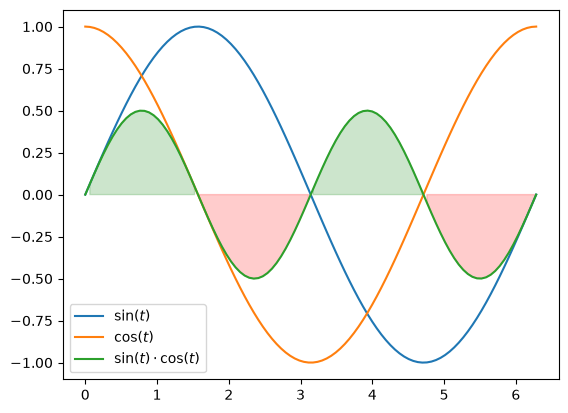

In [10]:
t = np.linspace(0, 2 * np.pi, 100)
f = np.sin(t)
g = np.cos(t)
fg = f * g

plt.plot(t, f, label=r"$\sin(t)$")
plt.plot(t, g, label=r"$\cos(t)$")
plt.plot(t, fg, label=r"$\sin(t) \cdot \cos(t)$")
plt.fill_between(t, fg, alpha=0.2, color="g", where=fg > 0)
plt.fill_between(t, fg, alpha=0.2, color="r", where=fg < 0)
plt.legend()
plt.show()

#### Beispiel 3

Bei Funktionen, die für $x\to\pm\infty$ gegen Null gehen kann man sagen, dass das Skalarprodukt den Überlapp der beiden Funktionen misst.

Als Beispiel betrachten wir die Normalverteilung mit Erwartungswert $\mu$ und Standardabweichung $\sigma=1$:

$$
    f(x,\mu) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}(x-\mu)^2}
$$

Wir berechnen das Skalarprodukt zwischen zwei dieser Normalverteilungen, eine mit $\mu=0$ und eine mit $\mu\neq 0$.

Das Integral kann grundsätzlich analytisch berechnet werden, siehe Wolfram|Alpha, doch die Rechnung ist nicht relevant für uns:

\begin{align*}
    \langle f(x,0), f(x,\mu) \rangle
    &= \int_{-\infty}^{+\infty} f(x,0) f(x,\mu) \,\mathrm{d}x \\
    &= \int_{-\infty}^{+\infty} \frac{1}{2\pi} e^{-\frac{1}{2}x^2} e^{-\frac{1}{2}\left(x-\mu\right)^2} \,\mathrm{d}x \\
    &= \frac{1}{2\pi} \int_{-\infty}^{+\infty} e^{-\frac{1}{2}\left(x^2 + (x-\mu)^2\right)} \,\mathrm{d}x \\
    &= \frac{1}{2\pi} \int_{-\infty}^{+\infty} e^{-\left(x^2 - x\mu + \frac{1}{2}\mu^2\right)} \,\mathrm{d}x \\
    &= \frac{1}{2\pi} \int_{-\infty}^{+\infty} e^{-\left(x^2 - x\mu + \frac{1}{4}\mu^2\right) - \frac{1}{4}\mu^2} \,\mathrm{d}x \\
    &= \frac{1}{2\pi} e^{-\frac{1}{4}\mu^2} \int_{-\infty}^{+\infty} e^{-\left(x - \frac{1}{2}\mu\right)^2} \,\mathrm{d}x \\
    &= \frac{1}{2\pi} e^{-\frac{1}{4}\mu^2} \sqrt{\pi} \\
    &= \frac{1}{2\sqrt{\pi}} e^{-\frac{1}{4}\mu^2}
\end{align*}

Im vorletzten Schritt wurde ein bekanntes Standardintegral verwendet: $\int_{-\infty}^{+\infty} e^{-x^2} \,\mathrm{d}x = \sqrt{\pi}$. 

Wir schauen uns das lieber graphisch an:

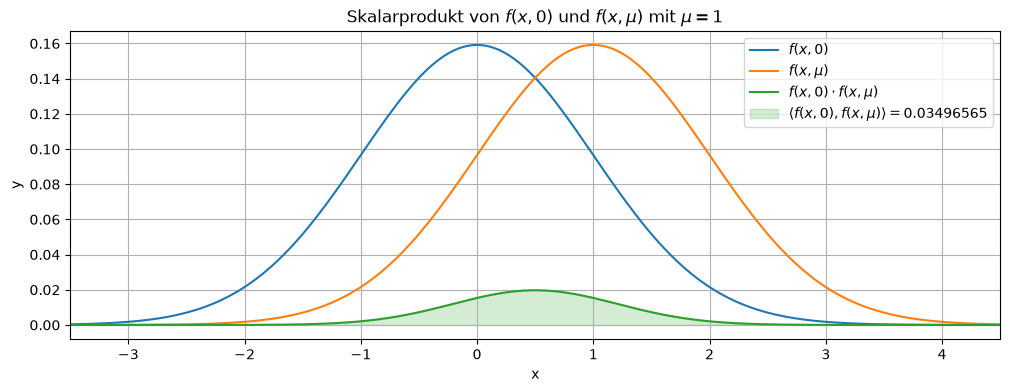

In [11]:
mu = 1
margin = 3.5
x = np.linspace(min(0, mu) - margin, max(0, mu) + margin, 200)

f = lambda x, mu: np.exp(-0.5 * (x - mu) ** 2) / (2 * np.pi)
y0 = f(x, 0)
y1 = f(x, mu)
y01 = y0 * y1

skalarprodukt, err = quad(lambda x: f(x, 0) * f(x, mu), -np.inf, np.inf)


plt.figure(figsize=(12, 4))
plt.plot(x, y0, label=r"$f(x,0)$")
plt.plot(x, y1, label=r"$f(x,\mu)$")
p = plt.plot(x, y01, label=r"$f(x,0) \cdot f(x,\mu)$")
plt.fill_between(
    x,
    y01,
    alpha=0.2,
    color=p[0].get_color(),
    label=f"$\\langle f(x,0), f(x,\mu) \\rangle = {skalarprodukt:.8f}$",
)
plt.legend()
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Skalarprodukt von $f(x,0)$ und $f(x,\mu)$ mit $\mu={mu}$")
plt.xlim(x.min(), x.max())
plt.show()

### 3. Gleitender Mittelwert und Faltung von Daten

#### Allgemein

Der [gleitende Mittelwert](https://de.wikipedia.org/wiki/Gleitender_Mittelwert) über die letzten $m$ Messwerte (*engl.* simple moving average, SMA) ist (siehe Einarbeiteung)

$$ \mathrm{SMA}^{(m)}_i = \frac{1}{m}\left(y_i + y_{i-1} + \ldots + y_{i-(m-1)}\right) = \frac{1}{m} \sum_{k=0}^{m-1} y_{i-k} \qquad\text{für}\quad m-1 \leq i < n $$

Mit Gewichten $w_k$ definiert man auch den gewichteten gleitenden Mittelwert (*engl.* weighted moving average, WMA):

$$ \mathrm{WMA}^{(m)}_i = \sum_{k=0}^{m-1} w_k y_{i-k}  \qquad\text{für}\quad m-1 \leq i < n $$

Typischerweise werden die Gewichte dreiecksförmig gewählt oder so, dass sie mit zunehmendem Abstand vom aktuellen Zeitpunkt $i$ abnehmen.

#### Beispiel

Wir vergleichen eine eigene Implementation mit der Funktion [`np.convolve`](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html).

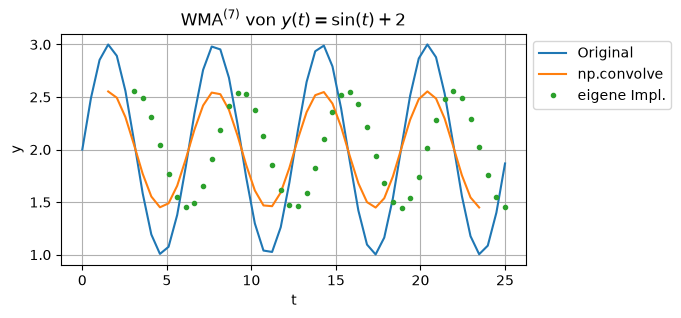

In [12]:
t = np.linspace(0, 25, 50)
y = np.sin(t) + 2

m = 7
w = np.full(m, 1 / m)

# Implementation von WMA wie in der Einarbeitung
wma = np.array([np.sum(w * y[i - (m - 1) : i + 1]) for i in range(m - 1, len(y))])

# Berechnung von WMA mit np.convolve
wma_conv = np.convolve(y, w, mode="valid")

t_conv = t[(m - 1) // 2 : -(m - 1) // 2]

plt.figure(figsize=(6, 3))
plt.plot(t, y, label="Original")
plt.plot(t_conv, wma_conv, label="np.convolve")
plt.plot(t[m - 1 :], wma, ".", label=f"eigene Impl.")
plt.legend(bbox_to_anchor=(1, 1))
plt.xlabel("t")
plt.ylabel("y")
plt.title(f"WMA$^{{({m})}}$ von $y(t) = \sin(t) + 2$")
plt.grid()
plt.show()

**Beobachtung**: Die Extrema des ursprünglichen Signals werden geglättet aber auch verschoben.
- Das kommt daher, dass deren Einfluss auf den gleitenden Mittelwert etwas verspätet eintritt.
- Deshalb wird der gleitende Mittelwert oft um die halbe Fensterbreite zurück verschoben.


**Abhängigkeit von der Fensterbreite**: Je grösser $m$, desto stärker wird das Signal geglättet.

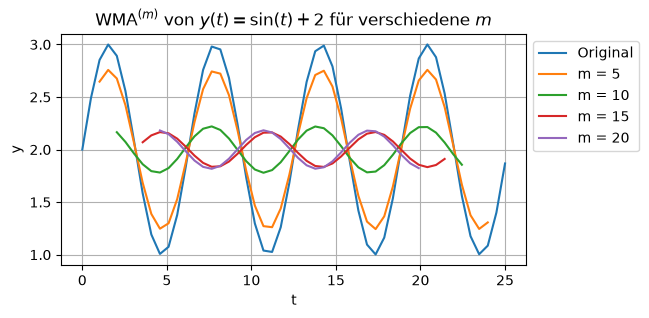

In [13]:
plt.figure(figsize=(6, 3))
plt.plot(t, y, label="Original")

for m in (5, 10, 15, 20):
    w = np.full(m, 1 / m)
    y_conv = np.convolve(y, w, mode="valid")
    # plt.plot(t[m - 1 :], y_conv, label=f"m = {m}")
    plt.plot(t[(m - 1) // 2 : -(m - 1) // 2], y_conv, label=f"m = {m}")

plt.legend(bbox_to_anchor=(1, 1))
plt.xlabel("t")
plt.ylabel("y")
plt.title(r"WMA$^{(m)}$ von $y(t) = \sin(t) + 2$ für verschiedene $m$")
plt.grid()
plt.show()

### 4. Faltung von Funktionen

#### Allgemein


Überträgt man das Konzept des gewichteten gleitenden Mittelwerts 

$$ \mathrm{WMA}^{(m)}_i = \sum_{k=0}^{m-1} w_k y_{i-k} $$

auf kontinuierliche Funktionen, so erhält man die [Faltung](https://de.wikipedia.org/wiki/Faltung_(Mathematik)) zweier Funktionen $w(t)$ und $f(t)$:

$$ (w * f)(t) = \int_{-\infty}^{\infty} w(\tau) f(t-\tau) \,\mathrm{d}\tau $$

Bemerkungen:

- Beim Analogieübergang von der diskreten Messreihe zu den kontinuierlichen Funktionen wurde wie folgt vorgegangen:
  - Der $i$-te Zeitpunkt wurde durch die Variable $t$ ersetzt.
  - Der $k$-te Zeitpunkt wurde durch die Variable $\tau$ ersetzt.
  - Die Summierung über $k$ wurde durch die Integration über $\tau$ ersetzt.
  - Die Gewichte $w_k$ wurden durch die Funktion $w(\tau)$ ersetzt.
  - Die um $k$ verschobenen Messwerte $y_{i-k}$ wurden durch die verschobene Funktion $f(t-\tau)$ ersetzt.
  - Die Integrationsgrenzen wurden auf $\pm\infty$ erweitert. Das heisst, dass die Funktionen $w(t)$ und $f(t)$ für alle $t\in\mathbb{R}$ definiert sein müssen, bzw. ausserhalb eines interessierenden Bereichs den Wert $0$ annehmen müssen.
- Die Faltung $w*f$ ist wieder eine Funktion und die Notation mit dem Stern ist üblich. Dies ist der Grund, weshalb man die Multiplikation auf keinen Fall mit einem Stern schreiben sollte.
- Die Funktion $w$ nimmt hier die Rolle der Gewichtungsfunktion (Fenster oder Filterfunktion) ein und $f$ diejenige der gemessenen Funktion (Signal).
- Die Faltung kommutativ, d.h., allgemein gilt:
  
  $$ f * g = g * f $$
  
  und somit die Interpretation der Rollen der Funktionen austauschbar.

Interpretation:

- In $f * g$ wird die Funktion $g(t)$ geglättet, indem rückwärtsblickend der gewichtete Mittelwert über $\tau$ berechnet wird.
- Die Gewichtungsfunktion $f(\tau)$ gibt an, wie stark der von $t$ aus um $\tau$ zurückliegende Wert gewichtet werden.

#### Beispiel 1: Faltung einer Sägezahnfunktion mit einer Rechteckfunktion

Als Signal betrachten wir eine Sägezahnfunktion $f(t)$

$$
    f(t) = \begin{cases}
        1-2t & \text{wenn } 0 \leq t \leq \frac{1}{2} \\
        0 & \text{sonst}
    \end{cases}
$$

und als Gewichtungsfunktion eine Rechteckfunktion $w(t)$:

$$
    w(t) = \begin{cases}
        1 & \text{wenn } |t| \leq \frac{1}{2} \\
        0 & \text{sonst}
    \end{cases}
$$

Machen wir uns zuerst mal ein Bild von den beiden Funktionen.

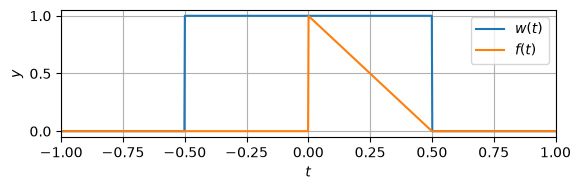

In [14]:
w = lambda t: np.where(np.abs(t) <= 0.5, 1, 0)
f = lambda t: np.where((0 <= t) & (t <= 0.5), 1 - 2 * t, 0)

t = np.linspace(-1, 1, 1000)
yw = w(t)
yf = f(t)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 2))
ax1.plot(t, yw, label="$w(t)$")
ax1.plot(t, yf, label="$f(t)$")
ax1.set_xlabel("$t$")
ax1.set_ylabel("$y$")
ax1.legend()
ax1.grid()
ax1.set_xlim(t.min(), t.max())
plt.tight_layout()
plt.show()

Die Berechnung des Faltungsintegrals ist in diesem Fall von Hand möglich aber nicht so einfach. Wir berechnen es numerisch und stellen das Resultat dar.

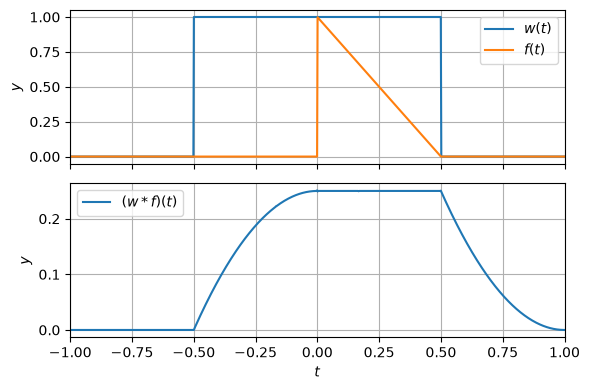

In [15]:
width = 1
half_width = width / 2
height = 1 / width

w = lambda t: np.where(np.abs(t) <= half_width, height, 0)
f = lambda t: np.where((0 <= t) & (t <= 0.5), 1 - 2 * t, 0)


def convolution(t):
    wf = lambda tau: w(tau) * f(t - tau)
    return quad(wf, -half_width, half_width)[0]


t = np.linspace(-1, 1, 1000)
yw = w(t)
yf = f(t)
yconv = np.vectorize(convolution)(t)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 4))

ax1.plot(t, yw, label="$w(t)$")
ax1.plot(t, yf, label="$f(t)$")
ax1.set_ylabel("$y$")
ax1.legend()
ax1.grid()
ax1.set_xlim(t.min(), t.max())

ax2.plot(t, yconv, label="$(w * f)(t)$")
ax2.set_xlabel("$t$")
ax2.set_ylabel("$y$")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

Aber was passiert denn während der Faltung?

In [16]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML

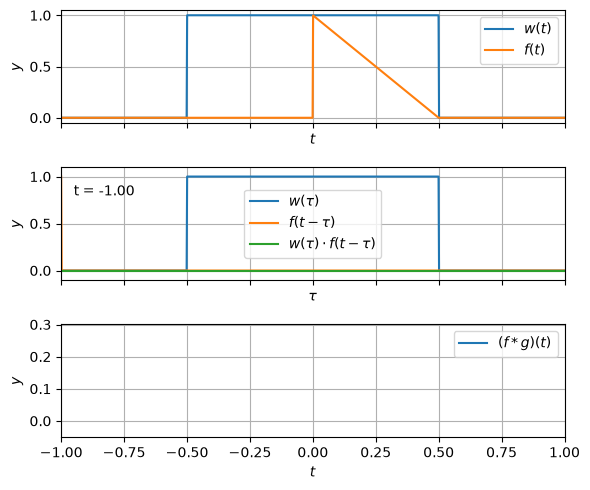

In [17]:
tau = t  # = np.linspace(-1, 1, 1000)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 5))

ax1.plot(t, yw, label="$w(t)$")
ax1.plot(t, yf, label="$f(t)$")
ax1.set_xlabel("$t$")
ax1.set_ylabel("$y$")
ax1.legend()
ax1.grid()

(p_w,) = ax2.plot([], [], label=r"$w(\tau)$")
(p_f,) = ax2.plot([], [], label=r"$f(t - \tau)$")
(p_wf,) = ax2.plot([], [], label=r"$w(\tau) \cdot f(t - \tau)$")
text = ax2.text(t.min() + 0.05, max(w(t).max(), f(t).max()) * 0.8, "")
ax2.set_xlim(t.min(), t.max())
ax2.set_ylim(min(w(t).min(), f(t).min()) - 0.1, max(w(t).max(), f(t).max()) + 0.1)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel("$y$")
ax2.legend()
ax2.grid()

(p_conv,) = ax3.plot([], [], label="$(f * g)(t)$")
ax3.set_xlim(t.min(), t.max())
ax3.set_ylim(yconv.min() - 0.05, yconv.max() + 0.05)
ax3.set_xlabel("$t$")
ax3.set_ylabel("$y$")
ax3.legend()
ax3.grid()

plt.tight_layout()


def update(t):
    p_w.set_data(tau, w(tau))
    p_f.set_data(tau, f(t - tau))
    p_wf.set_data(tau, w(tau) * f(t - tau))
    p_conv.set_data(tau[tau <= t], yconv[tau <= t])
    text.set_text(f"t = {t:.2f}")
    return (p_w, p_f, p_wf, p_conv, text)


t_frames = np.linspace(-1, 1, 200)
ani = FuncAnimation(fig, update, frames=t_frames, interval=50, blit=True)

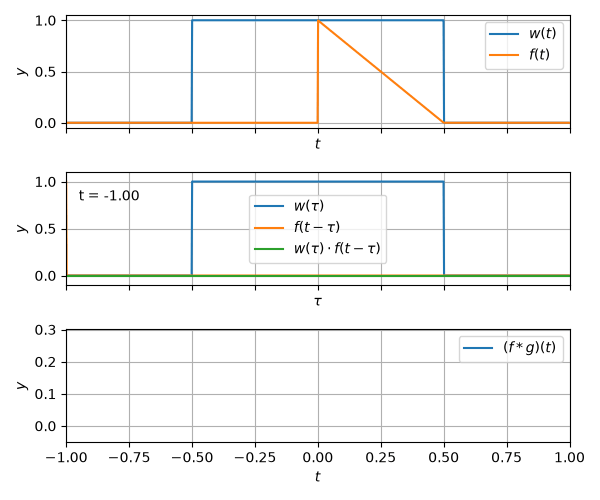

In [18]:
# Animation als GIF speichern und anzeigen (funktioniert in HTML und PDF)
from IPython.display import Image

ani.save("convolution_ani.gif", writer="pillow", fps=20)
plt.close(fig)
Image(filename="convolution_ani.gif")

#### Beispiel 2: Glättung des Sinus mit einer symmetrischen Rechteckfunktion

Als Gewichtungsfunktion nehmen wir wieder symmetrische Rechteckfunktion mit Länge 1:

$$ f(t) = \mathrm{rect}(t) = \begin{cases} 1 & \text{ wenn } |t| \leq \frac{1}{2} \\  0 & \text{ sonst } \end{cases} $$

\begin{align*}
    (\mathrm{rect} * \sin)(t) &= \int_{-\infty}^{\infty} \mathrm{rect}(\tau) \sin(t-\tau) \,\mathrm{d}\tau \\
    &= \int_{-\frac{1}{2}}^{\frac{1}{2}} \sin(t-\tau) \,\mathrm{d}\tau \\
    &= \bigg[ \cos(t-\tau) \bigg]_{-\frac{1}{2}}^{\frac{1}{2}} \\
    &= \cos\left(t-\tfrac{1}{2}\right) - \cos\left(t+\tfrac{1}{2}\right) \\
    &= 2\sin(\tfrac{1}{2}) \sin(t)
\end{align*}

wobei die letzte Gleichheit aus dem Additionstheorem für den Cosinus folgt:

$$ \cos(\alpha\pm\beta) = \cos(\alpha)\cos(\beta) ∓ \sin(\alpha)\sin(\beta) $$

Der Sinus wird durch die Faltung mit der symmetrischen Rechteckfunktion einfach um einen Faktor $2\sin(\tfrac{1}{2})\approx 0.9589$ gestaucht.

Für die numerische Berechnung mit [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) brauchen wir noch die Funktion [`np.vectorize`](https://numpy.org/doc/stable/reference/generated/numpy.vectorize.html), um die Faltung auf ein Array anwenden zu können.

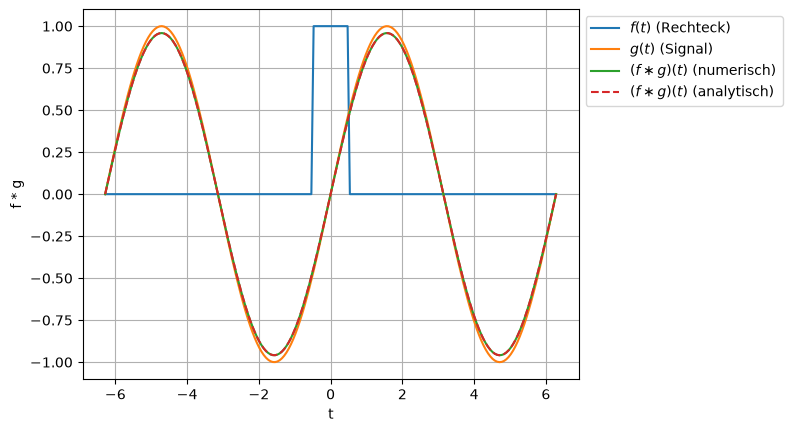

In [19]:
half_width = 0.5
f = lambda t: np.where(np.abs(t) > half_width, 0, 1 / (2 * half_width))
g = np.sin


def convolution(t):
    fg = lambda tau: f(tau) * g(t - tau)
    return quad(fg, -half_width, half_width)[0]


t = np.linspace(-2 * np.pi, 2 * np.pi, 200)
y = np.vectorize(convolution)(t)

plt.plot(t, f(t), label=r"$f(t)$ (Rechteck)")
plt.plot(t, g(t), label=r"$g(t)$ (Signal)")
plt.plot(t, y, label=r"$(f \ast g)(t)$ (numerisch)")
plt.plot(t, 2 * np.sin(1 / 2) * np.sin(t), "--", label=r"$(f \ast g)(t)$ (analytisch)")
plt.xlabel("t")
plt.ylabel("f * g")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

#### Beispiel 3: Glättung des Sinus mit einer rückwärtsblickenden Rechteckfunktion

Analog zum diskreten Beispiel weiter oben sei nun die Gewichtungsfunktion eine Rechteckfunktion der Länge $\Delta t$:

$$ f(\tau) = \frac{1}{\Delta t} \begin{cases} 1 & \text{ für } 0 \leq \tau \leq \Delta t \\ 0 & \text{ sonst } \end{cases} $$

\begin{align*}
(f * \sin)(t) &= \int_{-\infty}^{\infty} f(\tau) \sin(t-\tau) \,\mathrm{d}\tau \\
&= \frac{1}{\Delta t} \int_{0}^{\Delta t} \sin(t-\tau) \,\mathrm{d}\tau \\
&= \frac{1}{\Delta t} \bigg[ \cos(t-\tau) \bigg]_{0}^{\Delta t} \\
&= \frac{1}{\Delta t} \left( \cos(t - \Delta t) - \cos(t) \right)
\end{align*}

In diesem Fall wird der Sinus nicht nur gestaucht, sonder auch etwas verschoben. D.h. die Wellenberge kommen etwas verzögert an.

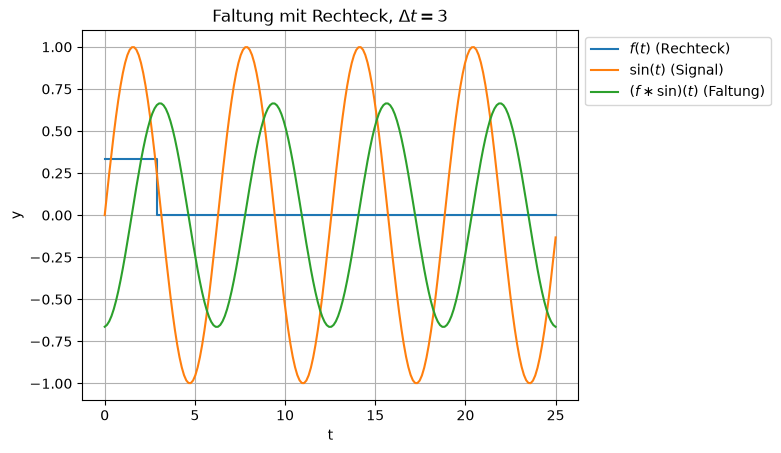

In [20]:
t = np.linspace(0, 25, 200)
y = np.sin(t)

Dt = 3
f = np.where(t <= Dt, 1 / Dt, 0)
fy = (np.cos(t - Dt) - np.cos(t)) / Dt

plt.step(t, f, label=r"$f(t)$ (Rechteck)")
plt.plot(t, y, label=r"$\sin(t)$ (Signal)")
plt.plot(t, fy, label=r"$(f \ast \sin)(t)$ (Faltung)")
plt.xlabel("t")
plt.ylabel("y")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid()
plt.title(f"Faltung mit Rechteck, $\\Delta t = {Dt}$")
plt.show()